In [5]:
# Import necessary libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

sns.set_style("whitegrid")

In [6]:
# Load dataset

df = pd.read_csv(r"C:\Users\senak\Desktop\dsa210 project\data\processed\movies_cleaned.csv")

df.head()

,title,year,budget,revenue,vote_average,vote_count,popularity,female_ratio,female_director,bechdelRating,imdbAverageRating,numVotes,runtimeMinutes,genre1,genre2,genre3
0,Avatar,2009.0,237000000,2787965087,7.2,11800,150.437577,0.144578,0,3.0,7.9,1389834.0,162.0,Action,Adventure,Fantasy
1,Pirates of the Caribbean: At World's End,2007.0,300000000,961000000,6.9,4500,139.082615,0.147059,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Spectre,2015.0,245000000,880674609,6.3,4466,107.376788,0.156627,0,1.0,6.8,467291.0,148.0,Action,Adventure,Thriller
3,The Dark Knight Rises,2012.0,250000000,1084939099,7.6,9106,112.312950,0.069620,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,John Carter,2012.0,260000000,284139100,6.1,2124,43.926995,0.222222,0,3.0,6.6,286786.0,132.0,Action,Adventure,Sci-Fi


In [ ]:

# Hypothesis 1: Female Directors and Movie Success
#
# H0: Female directors do not affect movie success
# H1: Movies directed by women perform better


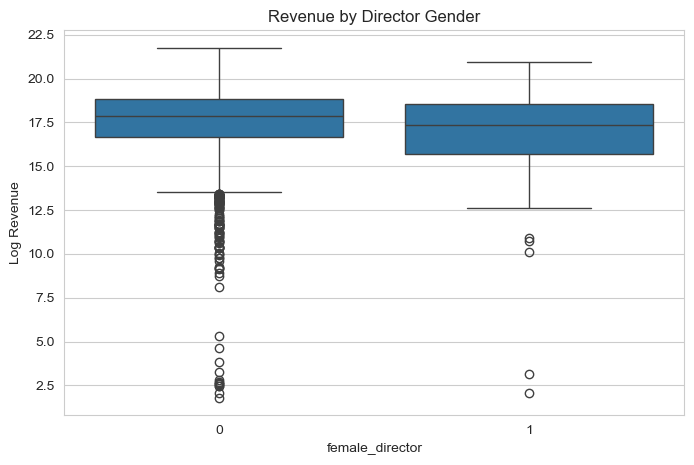

In [ ]:
# Compare revenue between female and male directors
# I used log scale because revenue is highly skewed

plt.figure(figsize=(8,5))

sns.boxplot(
    x='female_director',
    y=np.log1p(df['revenue']),
    data=df
)

plt.title("Revenue by Director Gender")
plt.ylabel("Log Revenue")

plt.show()

In [11]:
# Separate groups

female_dir = df[df['female_director']==1]['revenue']
male_dir = df[df['female_director']==0]['revenue']

# Perform t-test

t_stat, p_value = stats.ttest_ind(
    female_dir,
    male_dir,
    equal_var=False
)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: -1.2361396336834591
P-value: 0.2181993728115373


In [ ]:


if p_value < 0.05:
    print("Female directors significantly affect revenue.")
else:
    print("No significant difference in revenue between director genders.")

No significant difference in revenue between director genders.


In [ ]:

# Hypothesis 2: Female Directors and IMDb Rating
#
# H0: Female directors do not affect IMDb ratings
# H1: Movies directed by women receive higher IMDb ratings


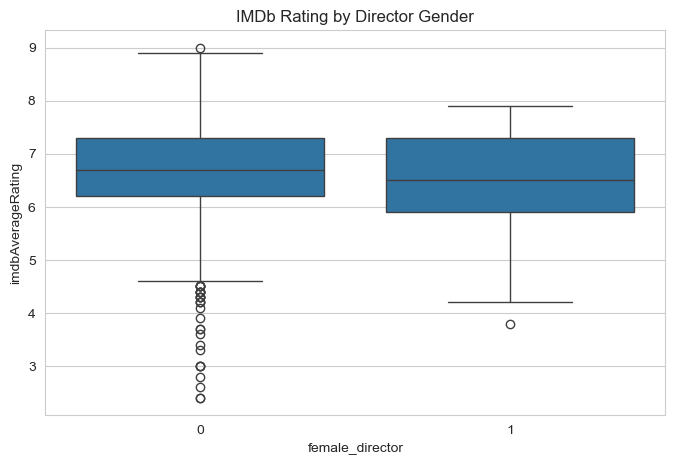

In [14]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='female_director',
    y='imdbAverageRating',
    data=df
)

plt.title("IMDb Rating by Director Gender")

plt.show()

In [17]:
female_dir = df[df['female_director']==1]['revenue'].dropna()
male_dir = df[df['female_director']==0]['revenue'].dropna()

print(len(female_dir), len(male_dir))

t_stat, p_value = stats.ttest_ind(
    female_dir,
    male_dir,
    equal_var=False
)

print("T-statistic:", t_stat)
print("P-value:", p_value)

147 3084
T-statistic: -1.2361396336834591
P-value: 0.2181993728115373


In [18]:
if p_value < 0.05:
    print("Female directors significantly affect IMDb ratings.")
else:
    print("No significant difference in IMDb ratings between director genders.")

No significant difference in IMDb ratings between director genders.


In [ ]:

# Hypothesis 3: Female Directors and Vote Count
#
# H0: Female directors do not affect vote count
# H1: Female directors influence vote count


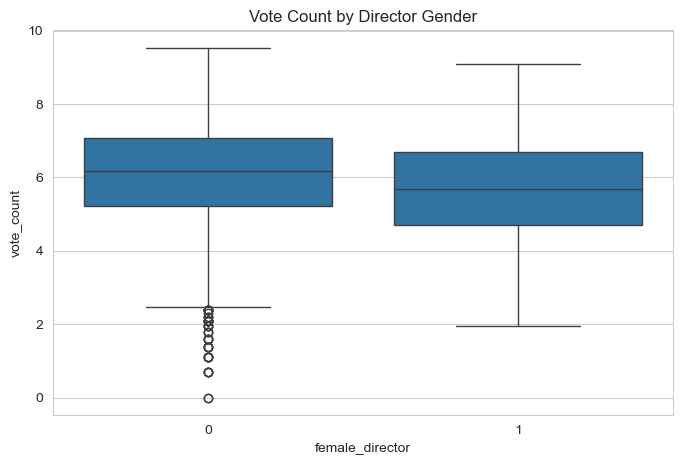

In [ ]:
#Plot Female Director vs Vote Count
plt.figure(figsize=(8,5))

sns.boxplot(
    x='female_director',
    y=np.log1p(df['vote_count']),
    data=df
)

plt.title("Vote Count by Director Gender")

plt.show()

In [33]:
female_dir = df[df['female_director']==1]['vote_count'].dropna()
male_dir = df[df['female_director']==0]['vote_count'].dropna()

t_stat, p_value = stats.ttest_ind(
    female_dir,
    male_dir,
    equal_var=False
)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: -2.49150140803285
P-value: 0.013694225990587864


In [34]:
if p_value < 0.05:
    print("Female directors significantly affect vote count.")
else:
    print("No significant difference in vote count.")

Female directors significantly affect vote count.


In [ ]:

# Hypothesis 4: Female Directors and Popularity
#
# H0: Female directors do not affect popularity
# H1: Female directors influence popularity


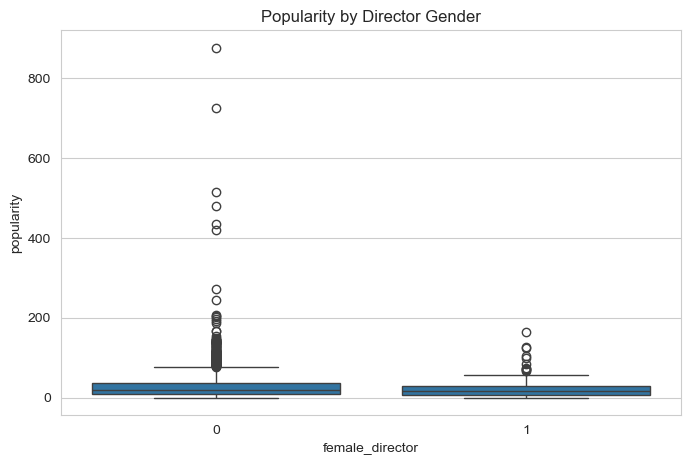

In [ ]:
# Plot Female Director vs Popularity
plt.figure(figsize=(8,5))

sns.boxplot(
    x='female_director',
    y='popularity',
    data=df
)

plt.title("Popularity by Director Gender")

plt.show()

In [37]:
female_dir = df[df['female_director']==1]['popularity'].dropna()
male_dir = df[df['female_director']==0]['popularity'].dropna()

t_stat, p_value = stats.ttest_ind(
    female_dir,
    male_dir,
    equal_var=False
)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: -2.5087886138511712
P-value: 0.01302345162925732


In [38]:
if p_value < 0.05:
    print("Female directors significantly affect popularity.")
else:
    print("No significant difference in popularity.")

Female directors significantly affect popularity.


In [ ]:

# Hypothesis 5: Female Representation and Revenue
#
# H0: Female representation does not affect revenue
# H1: Movies with more female representation earn more


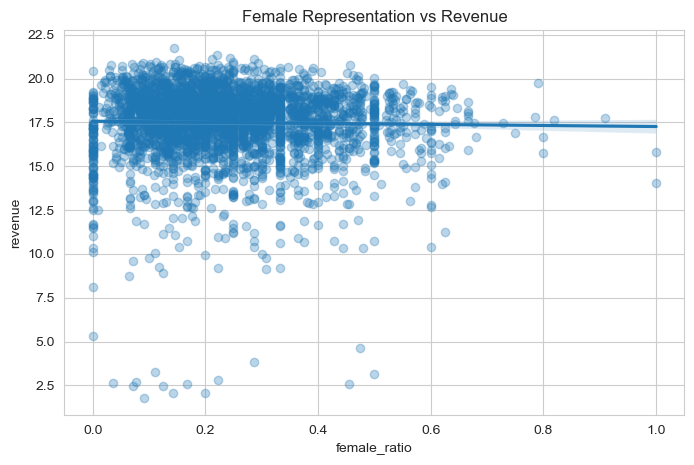

In [ ]:
#Plot Female Representation vs Revenue
plt.figure(figsize=(8,5))

sns.regplot(
    x='female_ratio',
    y=np.log1p(df['revenue']),
    data=df,
    scatter_kws={'alpha':0.3}
)

plt.title("Female Representation vs Revenue")

plt.show()

In [21]:
corr, p_value = stats.pearsonr(
    df['female_ratio'].dropna(),
    df['revenue'].dropna()
)

print("Correlation:", corr)
print("P-value:", p_value)

Correlation: -0.08335973821363925
P-value: 2.087631022814956e-06


In [22]:
if p_value < 0.05:
    print("Female representation significantly affects revenue.")
else:
    print("No significant relationship between female representation and revenue.")

Female representation significantly affects revenue.


In [ ]:

# Hypothesis 6: Female Representation and IMDb Rating
#
# H0: Female representation does not affect IMDb ratings
# H1: Movies with more female representation receive higher ratings


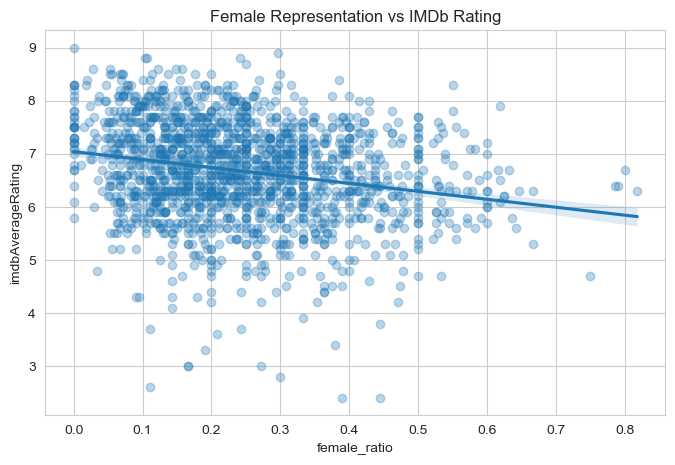

In [ ]:
# Female Representation vs IMDb Rating
plt.figure(figsize=(8,5))

sns.regplot(
    x='female_ratio',
    y='imdbAverageRating',
    data=df,
    scatter_kws={'alpha':0.3}
)

plt.title("Female Representation vs IMDb Rating")

plt.show()

In [25]:
if p_value < 0.05:
    print("Female representation significantly affects IMDb ratings.")
else:
    print("No significant relationship between female representation and ratings.")

Female representation significantly affects IMDb ratings.


In [ ]:

# Hypothesis 7: Female Representation and Vote Count
#
# H0: Female representation does not affect vote count
# H1: Movies with higher female representation receive more votes


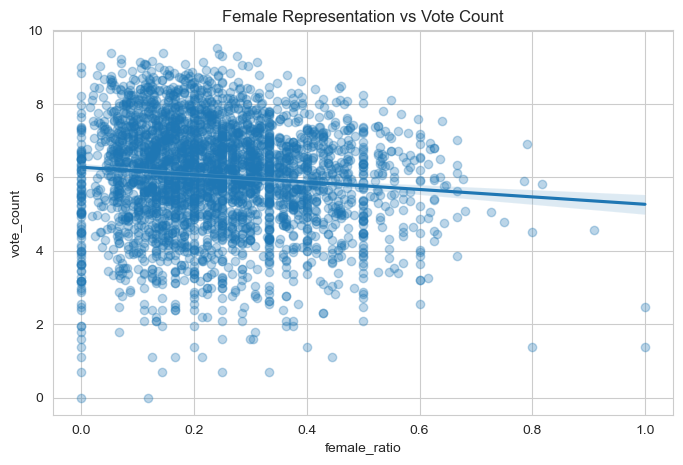

In [ ]:
#Plot Female Representation vs Vote Count
plt.figure(figsize=(8,5))

sns.regplot(
    x='female_ratio',
    y=np.log1p(df['vote_count']),
    data=df,
    scatter_kws={'alpha':0.3}
)

plt.title("Female Representation vs Vote Count")

plt.show()

In [40]:
corr, p_value = stats.pearsonr(
    df['female_ratio'].dropna(),
    df['vote_count'].dropna()
)

print("Correlation:", corr)
print("P-value:", p_value)

Correlation: -0.13773186455648023
P-value: 3.73810929764972e-15


In [41]:
if p_value < 0.05:
    print("Female representation significantly affects vote count.")
else:
    print("No significant relationship between female representation and vote count.")

Female representation significantly affects vote count.


In [ ]:

# Hypothesis 8: Female Representation and Popularity
#
# H0: Female representation does not affect popularity
# H1: Movies with higher female representation are more popular


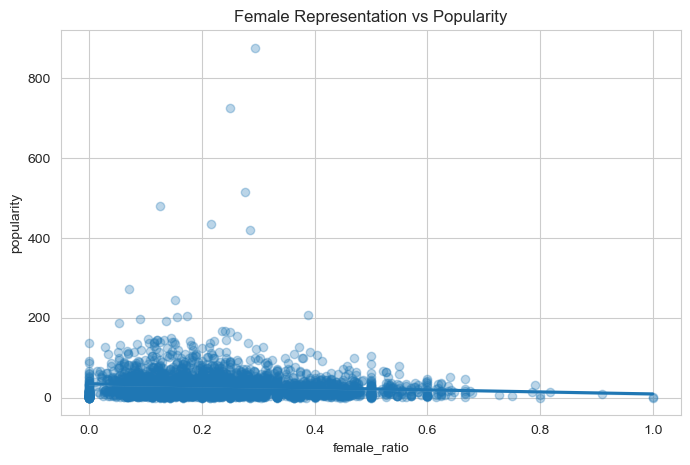

In [ ]:
#Plot Female Representation vs Popularity
plt.figure(figsize=(8,5))

sns.regplot(
    x='female_ratio',
    y='popularity',
    data=df,
    scatter_kws={'alpha':0.3}
)

plt.title("Female Representation vs Popularity")

plt.show()

In [44]:
corr, p_value = stats.pearsonr(
    df['female_ratio'].dropna(),
    df['popularity'].dropna()
)

print("Correlation:", corr)
print("P-value:", p_value)

Correlation: -0.09902969687613881
P-value: 1.6933443819877437e-08


In [45]:
if p_value < 0.05:
    print("Female representation significantly affects popularity.")
else:
    print("No significant relationship between female representation and popularity.")

Female representation significantly affects popularity.
